In [2]:
# Jupyter magics (if using a notebook)
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib import colors
import seaborn as sns
import os
import warnings

# Stats / modeling
import scipy.stats as sp
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform

# XGBoost
from xgboost import XGBClassifier

# PyTorch / Skorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from skorch import NeuralNetClassifier
from skorch.callbacks import EpochScoring, EarlyStopping

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define risk model - for simulation 

In [3]:
def set_model(model_name, alpha, theta):
    if model_name == 'multiplicative':
        x = np.hstack((np.array([alpha * ((1 + theta) ** 4),
                                 alpha * ((1 + theta) ** 2),
                                 alpha,
                                 alpha * ((1 + theta) ** 2),
                                 alpha * (1 + theta)]),
                       np.repeat(alpha, 4)))
    elif model_name == 'dab1':
        # Custom risk model: additive at locus B (DAB1) when APOE genotype == 2
        # Odds ratios specific to our scenario - this model is used for our epsistatic effect not the above multiplicative 
        x = np.array([
            1, 1, 1,    # APOE = 0 (AA)
            apoe_or, apoe_or, apoe_or,    # APOE = 1 (Aa)
            apoe_or ** 2, (apoe_or ** 2) * dab1_or, (apoe_or ** 2) * (dab1_or ** 2) # APOE = 2 (aa), DAB1 = 1 or 2 has elevated risk
        ])
    else:
        raise ValueError('Model type not recognised')

    return x
    
# The append_missing_counts function checks if all expected genotype keys are present in the data.
# If any are missing, it adds those keys with zero counts.
# This is useful to avoid errors in analyses that expect a complete set of genotype categories.

def append_missing_counts(counts):
    # Define all expected keys
    all_keys = ['00', '10', '01', '11', '02', '20', '12', '21', '22']

    # Check which keys are present in the input Series
    present = [x in counts.index for x in all_keys]

    # If not all keys are present, add the missing ones with count 0
    if sum(present) != len(all_keys):
        missing_keys = [key for key, is_present in zip(all_keys, present) if not is_present]

        # Create a Series for the missing counts, initialized to 0
        extra_counts = pd.Series(np.zeros(len(missing_keys), dtype=int),
                                 index=missing_keys)

        # Use pd.concat to combine the original counts with the new missing counts
        counts = pd.concat([counts, extra_counts])

    return counts
    
# This pprint_vector function displays genotype combination data in a nicely formatted way
def pprint_vector(vector):
    x = pd.DataFrame(np.reshape(vector, (3, 3)),
                     columns=["bb", "Bb", "BB"],
                     index=["AA", "Aa", "aa"])
    print('Risk alleles: A/B\n')
    print(x)

### Set HWE frequencies based on risk model 

In [4]:
# Calculate exact genotype frequencies assuming HWE

def set_hwe_at_locus(maf):
    p = maf
    q = 1 - p

    return np.hstack((p ** 2, 2 * p * q, q ** 2))[::-1]

# Calculates the joint genotype probabilities for two loci under the assumption that the two loci are independent.
def set_control_pgi(hwe_a, hwe_b):
    # creates P(Gi), the vector of probabilities of each two-locus genotype combination
    pgi_controls = np.hstack((
        hwe_a[0] * hwe_b,
        hwe_a[1] * hwe_b,
        hwe_a[2] * hwe_b\
    ))

    return pgi_controls
    
# Adjusts control genotype frequencies by risk multipliers (the model vector) to simulate frequencies in cases.
def set_case_pgi(pgi_controls, model):
    pgi_cases = np.multiply(pgi_controls, model)

    return pgi_cases

# This function samples length number of items randomly but weighted by specified probabilities from the given options 
def weighted_random_choice(options, length, probabilities):
    # lifted from here: https://glowingpython.blogspot.com/2012/09/weighted-random-choice.html
    t = np.cumsum(probabilities)
    s = np.sum(probabilities)
    
    return options[np.searchsorted(t, np.random.rand(length) * s)]

### Create simulated dataset 

In [5]:
# Sets the random seed so the simulation results are reproducible.
# This ensures every run with the same seed gives the same simulated data.
    
def simulate(maf_a, maf_b, n_cases, n_controls, seed, model):
    print('Current seed: {}'.format(seed))
    np.random.seed(seed)

    # Calculate genotype frequencies at each locus assuming HWE
    hwe_a, hwe_b = [set_hwe_at_locus(m) for m in (maf_a, maf_b)]
    # Calculate joint genotype frequencies in controls
    control_pgi = set_control_pgi(hwe_a, hwe_b)
    # Adjust joint genotype frequencies for cases using the genetic risk model
    case_pgi = set_case_pgi(control_pgi, model)

    # Define the genotype combinations as strings
    alleles = np.array(["aa_bb", "aa_Bb", "aa_BB", "Aa_bb", "Aa_Bb", "Aa_BB", "AA_bb", "AA_Bb", "AA_BB"])[::-1]
    print(alleles)
    # Sample genotype combinations for cases and controls based on probabilities
    interactions = np.hstack((
        weighted_random_choice(alleles, n_cases, case_pgi),
        weighted_random_choice(alleles, n_controls, control_pgi)
    ))

    # Convert string genotypes to numeric genotype format for analysis
    snps = (pd.DataFrame({'snps': interactions})
              .snps.str.split('_', expand=True)
              .replace({'aa': 2, 'aA': 1, 'Aa': 1, 'AA': 0,
                        'bb': 2, 'bB': 1, 'Bb': 1, 'BB': 0}).infer_objects(copy=False)
              .rename(columns={0: 'SNP_A', 1: 'SNP_B'}))
    # Add disease status label    
    snps['Status'] = np.hstack((np.repeat(1, n_cases), np.repeat(0, n_controls)))

    # Return the final simulated dataset
    return snps.loc[:, ['Status', 'SNP_A', 'SNP_B']]

### Validate Simulated dataset 

In [6]:
# This function is used to validate your simulated datase
def check_sim(df, maf_a, maf_b, model):
    # Compute expected genotype frequencies under HWE
    hwe_a, hwe_b = [set_hwe_at_locus(m) for m in (maf_a, maf_b)]

    # Print HWE vs empirical genotype proportions
    bar = '####################################'
    print('{} {} {}'.format(bar, 'Genotype Proportions', bar))
    print('SNP_A\n'
          'Expected Genotype Proportions: {}\n'
          'Empirical Genotype Proportions: {}\n'.format(hwe_a,
                                                        df.SNP_A.value_counts(normalize=True)
                                                        .loc[[2, 1, 0]].values.tolist()))
    print('SNP_B\n'
          'Expected Genotype Proportions: {}\n'
          'Empirical Genotype Proportions: {}\n'.format(hwe_b,
                                                        df.SNP_B.value_counts(normalize=True)
                                                        .loc[[2, 1, 0]].values.tolist()))

    # Count genotype combinations in cases vs controls
    observed_counts_cases = df.loc[df['Status'] == 1, ['SNP_A', 'SNP_B']].apply(lambda x: ''.join(x.astype(str).tolist()),
                                                      axis=1).value_counts()
    observed_counts_controls = df.loc[df['Status'] == 0, ['SNP_A', 'SNP_B']].apply(lambda x: ''.join(x.astype(str).tolist()),
                                                      axis=1).value_counts()
    # Ensure all genotype combinations exist (even if count = 0)
    observed_counts_cases = append_missing_counts(observed_counts_cases)
    observed_counts_controls = append_missing_counts(observed_counts_controls)

    # show raw sample counts in cases and controls
    print('{} {} {}'.format(bar, 'Two-Locus Genotype Counts', bar))
    genotypes = ['00', '10', '01', '11', '02', '20', '12', '21', '22']
    print('Observed Counts in Cases')
    case_counts = [observed_counts_cases[x] for x in genotypes]
    pprint_vector([case_counts[i] for i in [4, 6, 8, 2, 3, 7, 0, 1, 5]])
    print('\nObserved Counts in Controls')
    control_counts = [observed_counts_controls[x] for x in genotypes]
    pprint_vector([control_counts[i] for i in [4, 6, 8, 2, 3, 7, 0, 1, 5]])

    # calculate odds and odds ratios (where AABB is baseline risk)
    print('\n{} {} {}'.format(bar, 'Two-Locus Odds Ratios', bar))
    odds = [observed_counts_cases[x] / observed_counts_controls[x] for x in genotypes]
    odds_ratios = [x / odds[0] for x in odds]
    print('Observed OR w.r.t baseline AABB')
    pprint_vector(['%.2f' % odds_ratios[i] for i in [4, 6, 8, 2, 3, 7, 0, 1, 5]])
    print('\nExpected OR')
    pprint_vector([model[x] for x in [2, 1, 0, 5, 4, 3, 8, 7, 6]])

### Define the functions 

In [7]:
# Run simulation with Kunkle-derived OR model
seed = 1
alpha = 3.33 
theta = 1.5
maf_a = 0.36  # APOE
maf_b = 0.04  # DAB1
apoe_or = np.exp(1.2017)  
dab1_or = 2.28
n_cases = 10000
n_controls = 10000
mod = set_model('dab1', alpha, theta)
df = simulate(maf_a, maf_b, n_cases, n_controls, seed=seed, model=mod)
check_sim(df, maf_a, maf_b, mod)

Current seed: 1
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
#################################### Genotype Proportions ####################################
SNP_A
Expected Genotype Proportions: [0.4096 0.4608 0.1296]
Empirical Genotype Proportions: [0.28935, 0.45115, 0.2595]

SNP_B
Expected Genotype Proportions: [0.9216 0.0768 0.0016]
Empirical Genotype Proportions: [0.0026, 0.09505, 0.90235]



/tmp/ipykernel_3518/2499391125.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'aa': 2, 'aA': 1, 'Aa': 1, 'AA': 0,


#################################### Two-Locus Genotype Counts ####################################
Observed Counts in Cases
Risk alleles: A/B

      bb    Bb    BB
AA     0     4    31
Aa    88   349   680
aa  1079  3993  3776

Observed Counts in Controls
Risk alleles: A/B

      bb    Bb    BB
AA     7     8     2
Aa   330   364    90
aa  3686  4305  1208

#################################### Two-Locus Odds Ratios ####################################
Observed OR w.r.t baseline AABB
Risk alleles: A/B

      bb    Bb     BB
AA  0.00  1.71  52.95
Aa  0.91  3.28  25.81
aa  1.00  3.17  10.68

Expected OR
Risk alleles: A/B

           bb         Bb         BB
AA   1.000000   1.000000   1.000000
Aa   3.325766   3.325766   3.325766
aa  57.498041  25.218439  11.060719


### Get the odds and OR with reference to the baseline of double homozygote for wild type

In [10]:
def get_odds(s):
    p = s.mean()
    
    return p / (1-p)

In [11]:
df_oddsdplot = (
    df.dropna()
      .groupby(['SNP_A', 'SNP_B'])['Status']
      .apply(get_odds)
      .reset_index()
      .rename(columns={'Status': 'Odds'})
      .assign(OR=lambda x: x['Odds'] / x.loc[(x['SNP_A'] == 0) & (x['SNP_B'] == 0), 'Odds'].values[0])
)

print(df_oddsdplot)



   SNP_A  SNP_B       Odds         OR
0      0      0   0.292729   1.000000
1      0      1   0.266667   0.910967
2      0      2   0.000000   0.000000
3      1      0   0.927526   3.168546
4      1      1   0.958791   3.275352
5      1      2   0.500000   1.708063
6      2      0   3.125828  10.678222
7      2      1   7.555556  25.810730
8      2      2  15.500000  52.949954


### Plot the Odds ratios into a graph 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib import colors


def plot_interaction(plot_name, figure_size=(12, 10), subplot_location=111,
                     fig=None, ax=None, axes_names=None, odds=None, force_z_lim=None, force_z_max=None,
                     move_by=(0, 0), round_z_max=None, z_ticker=None, allele_coding='AB', colmap='sequential',
                     cmap_midpoint=0, vmin=None, vmax=None, zpos=0):

    if fig is None:
        fig = plt.figure(figsize=figure_size)
    if ax is None:
        ax = fig.add_subplot(subplot_location, projection='3d')

    xpos = [0, 1, 2, 0, 1, 2, 0, 1, 2]
    ypos = [0, 0, 0, 1, 1, 1, 2, 2, 2]
    zpos = np.repeat(zpos, len(ypos)).tolist()
    dx = np.repeat(0.5, 9)
    dy = np.repeat(0.5, 9)
    dz = odds if odds is not None else [1, 1, 1, 2, 2, 1, 3, 2, 1]

    force_z_max = force_z_max if force_z_max is not None else np.ceil(np.max(dz))
    vmin = vmin if vmin is not None else np.floor(np.min(dz))
    vmax = vmax if vmax is not None else np.ceil(np.max(dz))

    # Set colormap
    if colmap == 'sequential':
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.Blues
    elif colmap == 'diverging':
        norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=cmap_midpoint, vmax=vmax)
        cmap = cm.RdBu
    else:
        raise ValueError('colmap type {} not recognised'.format(colmap))

    m = cm.ScalarMappable(norm=norm, cmap=cmap)
    bar_colours = [m.to_rgba(x) for x in dz]

    axis_font = {'fontsize': 12}
    title_font = {'fontsize': 20, 'fontweight': 'medium'}

    this_plot = ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=bar_colours, shade=False)
    if force_z_lim is not None:
        ax.set_zlim(force_z_lim[0], force_z_lim[1])
    this_plot.set_edgecolor('white')

    if plot_name:
        ax.set_title(plot_name, fontdict=title_font, y=1.04)

    if axes_names is None:
        axes_names = ['Locus A', 'Locus B', 'Odds Ratio']
    ax.set_xlabel(axes_names[0], fontdict=axis_font, labelpad=10)
    ax.set_ylabel(axes_names[1], fontdict=axis_font, labelpad=10)
    ax.set_zlabel(axes_names[2], fontdict=axis_font, labelpad=10, rotation=270)

    # Hide 3D axis panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')

    # Optional tick labels
    if allele_coding == 'AB':
        ax.set_xticks([0, 1, 2])
        ax.set_yticks([0, 1, 2])
        ax.set_xticklabels(['AA', 'Aa', 'aa'])
        ax.set_yticklabels(['bb', 'Bb', 'BB'])
    elif allele_coding == '012':
        ax.set_xticks([0, 1, 2])
        ax.set_yticks([0, 1, 2])
        ax.set_xticklabels(['0', '1', '2'])
        ax.set_yticklabels(['0', '1', '2'])
    else:
        raise ValueError('Must be AB or 012')

    # Configure Z-axis ticks
    round_z_max = (round(force_z_max * 2) / 2) + 1 if force_z_lim is None else force_z_lim[1]
    round_z_min = np.floor(np.min(dz)) if force_z_lim is None else force_z_lim[0]
    z_ticker = 1 if z_ticker is None else z_ticker
    ax.set_zticks(np.arange(round_z_min, round_z_max, z_ticker).tolist())
    ax.view_init(azim=-35)
    ax.grid(False)

    # Adjust position
    l, b, w, h = ax.get_position().bounds
    ax.set_position([l + move_by[0], b + move_by[1], w, h])

    return ax


def plot_quant_interaction(plot_name, figure_size=(12, 10), subplot_location=111, fig=None, axes_names=None, f=None,
                           move_by=[0, 0], ax=None):
    if fig is None:
        fig = plt.figure(figsize=figure_size)
    if ax is None:
        ax = fig.add_subplot(subplot_location, projection='3d')

    x = np.linspace(2, 0, 30)
    y = np.linspace(0, 2, 30)
    if f is None:
        def f(x, y):
            x = 2 - x
            return x + y + x**2 + y**2 + x*y + (x**2)*(y**2)

    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    axis_font = {'fontsize': 12}
    title_font = {'fontsize': 20, 'fontweight': 'medium'}

    ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis', edgecolor='none')
    ax.set_title(plot_name, fontdict=title_font, y=1.04)

    if axes_names is None:
        axes_names = ['Locus A', 'Locus B', 'Phenotype']
    ax.set_xlabel(axes_names[0], fontdict=axis_font, labelpad=10)
    ax.set_ylabel(axes_names[1], fontdict=axis_font, labelpad=10)
    ax.set_zlabel(axes_names[2], fontdict=axis_font, labelpad=10)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')

    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(['AA', 'Aa', 'aa'])
    ax.set_yticklabels(['bb', 'Bb', 'BB'])
    ax.view_init(azim=-35)
    ax.grid(False)

    l, b, w, h = ax.get_position().bounds
    ax.set_position([l + move_by[0], b + move_by[1], w, h])

    return ax

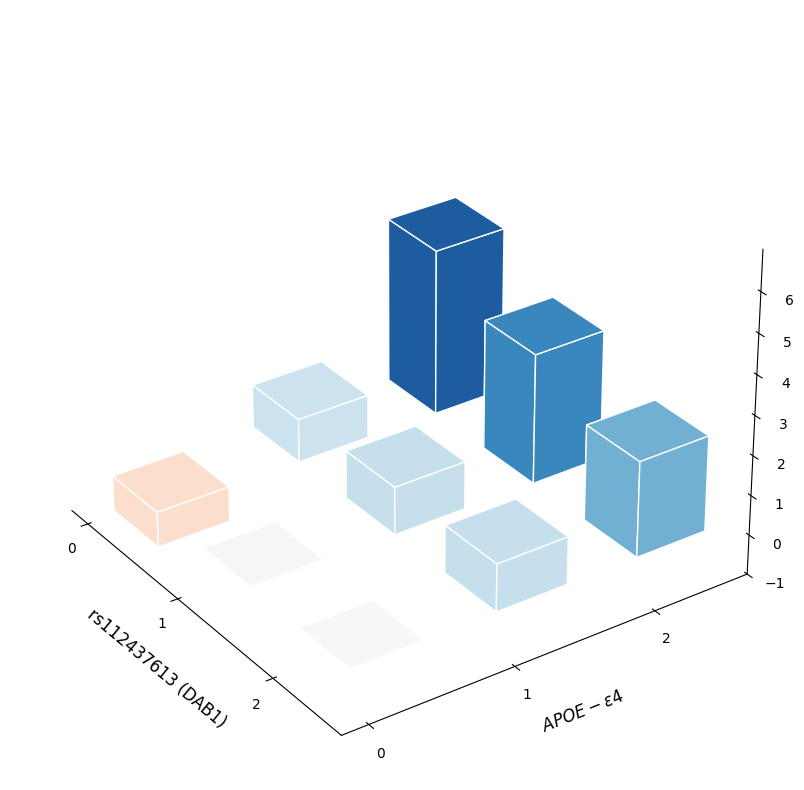

In [ ]:
mymod = np.log(df_oddsdplot.sort_values(['SNP_A', 'SNP_B'], ascending=[True, False]).OR).tolist()

ax = plot_interaction(
    plot_name='',
    odds=mymod,
    axes_names=['DAB1', '$APOE-\\epsilon4$', ''],
    round_z_max=None,
    z_ticker=1,
    force_z_lim=(-1, 7),
    allele_coding='012',
    colmap='diverging',
    zpos=0,
    vmin=-5,
    vmax=5
)

ax.set_zlabel('log(OR)', labelpad=5, rotation=0, fontsize=15)

fig = ax.get_figure()  # get the figure from axes

odds_graph_dir = "/scratch/c.c2029098/dementia_ml_project/results/figures/Simulations"
import os
fig.savefig(os.path.join(odds_graph_dir, "odds_graph_UKBB_40000.png"))

### Run full logistic regression model with interaction term 

In [13]:
# Suppress FutureWarnings and any other warnings
warnings.filterwarnings("ignore")

def sim_and_split(maf_a, maf_b, n_cases, n_controls, seed, model, test_size=0.3):
    # Generate simulated dataset
    df = simulate(maf_a, maf_b, n_cases, n_controls, seed, model)
    
     # Add interaction term
    df['SNP_AxB'] = df['SNP_A'] * df['SNP_B']

    # Use SNP_A, SNP_B, and interaction for features
    X = df[['SNP_A', 'SNP_B', 'SNP_AxB']]
    y = df['Status'].values
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y)
    
    return X_train, y_train, X_test, y_test

def run_simulations(mod, maf_a, maf_b, n_cases, n_controls, num_reps=10, test_size=0.3):
    aucs = []
    
    for i in range(num_reps):
        np.random.seed(i)

        # Generate split with specified parameters
        X_train, y_train, X_test, y_test = sim_and_split(
            maf_a=maf_a,
            maf_b=maf_b,
            n_cases=n_cases,
            n_controls=n_controls,
            seed=i,
            model=mod,
            test_size=test_size
        )

        # Fit logistic regression (unpenalised)
        logistic_regression = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
        logistic_regression.fit(X_train, y_train)

        # Predict and evaluate
        y_pred_prob = logistic_regression.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        aucs.append(auc)

    avg_auc = np.mean(aucs)
    print(f'Average ROC AUC over {num_reps} simulations: {avg_auc:.4f}')
    return aucs

alpha = 3.33
theta = 1.5
mod = set_model('dab1', alpha, theta)

aucs = run_simulations(
    mod=mod,
    maf_a=0.36,
    maf_b=0.04,
    n_cases=10000,
    n_controls=10000,
    num_reps=100
)


Current seed: 0
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 1
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 2
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 3
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 4
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 5
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 6
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 7
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 8
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 9
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 10
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current s

### Run logistic regression - without interaction term 

In [15]:
# Suppress FutureWarnings and any other warnings
warnings.filterwarnings("ignore")

def sim_and_split(maf_a, maf_b, n_cases, n_controls, seed, model, test_size=0.3):
    # Generate simulated dataset
    df = simulate(maf_a, maf_b, n_cases, n_controls, seed, model)

    # Use ONLY main effects (no interaction term)
    X = df[['SNP_A', 'SNP_B']]
    y = df['Status'].values

    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )
    return X_train, y_train, X_test, y_test


def run_simulations(mod, maf_a, maf_b, n_cases, n_controls, num_reps=10, test_size=0.3):
    aucs = []

    for i in range(num_reps):
        np.random.seed(i)

        # Generate split with specified parameters
        X_train, y_train, X_test, y_test = sim_and_split(
            maf_a=maf_a,
            maf_b=maf_b,
            n_cases=n_cases,
            n_controls=n_controls,
            seed=i,
            model=mod,
            test_size=test_size
        )

        # Fit logistic regression (no interaction term)
        # Note: use penalty='none' explicitly
        logreg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
        logreg.fit(X_train, y_train)

        # Predict and evaluate
        y_pred_prob = logreg.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        aucs.append(auc)

    avg_auc = np.mean(aucs)
    print(f'Average ROC AUC over {num_reps} simulations (no interaction): {avg_auc:.4f}')
    return aucs


# ---- Run ----
alpha = 3.33
theta = 1.5
mod = set_model('dab1', alpha, theta)

aucs = run_simulations(
    mod=mod,
    maf_a=0.36,
    maf_b=0.04,
    n_cases=10000,
    n_controls=10000,
    num_reps=100
)


Current seed: 0
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 1
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 2
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 3
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 4
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 5
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 6
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 7
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 8
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 9
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current seed: 10
['AA_BB' 'AA_Bb' 'AA_bb' 'Aa_BB' 'Aa_Bb' 'Aa_bb' 'aa_BB' 'aa_Bb' 'aa_bb']
Current s

### P-value of interaction terms

In [16]:
import statsmodels.formula.api as smf

# Logistic regression WITHOUT interaction term
model_no_inter = smf.logit('Status ~ SNP_A + SNP_B', data=df).fit(disp=0)

print("===== Logistic Regression WITHOUT Interaction Term =====")
print("Coefficients (betas):")
print(model_no_inter.params, "\n")

print("Standard Errors:")
print(model_no_inter.bse, "\n")

print("P-values:")
print(model_no_inter.pvalues, "\n")

print("95% Confidence Intervals:")
print(model_no_inter.conf_int(), "\n")

print("Model summary:")
print(model_no_inter.summary())

# Logistic regression WITH interaction term
model_inter = smf.logit('Status ~ SNP_A + SNP_B + SNP_A:SNP_B', data=df).fit(disp=0)

print("\n\n===== Logistic Regression WITH Interaction Term =====")
print("Coefficients (betas):")
print(model_inter.params, "\n")

print("Standard Errors:")
print(model_inter.bse, "\n")

print("P-values:")
print(model_inter.pvalues, "\n")

print("95% Confidence Intervals:")
print(model_inter.conf_int(), "\n")

print("Model summary:")
print(model_inter.summary())


===== Logistic Regression WITHOUT Interaction Term =====
Coefficients (betas):
Intercept   -1.296846
SNP_A        1.234962
SNP_B        0.234188
dtype: float64 

Standard Errors:
Intercept    0.028579
SNP_A        0.022928
SNP_B        0.051610
dtype: float64 

P-values:
Intercept    0.000000
SNP_A        0.000000
SNP_B        0.000006
dtype: float64 

95% Confidence Intervals:
                  0         1
Intercept -1.352860 -1.240833
SNP_A      1.190025  1.279900
SNP_B      0.133035  0.335341 

Model summary:
                           Logit Regression Results                           
Dep. Variable:                 Status   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19997
Method:                           MLE   Df Model:                            2
Date:                Thu, 28 Aug 2025   Pseudo R-squ.:                  0.1279
Time:                        21:21:59   Log-Likelihood:                -12090.
converge